# 02 Exploratory Data Analysis

This notebook explores the cleaned retail transaction dataset created in `01_data_cleaning.ipynb`.

The goal is to understand overall business performance and prepare dashboard-ready tables for Tableau.

Scope of this notebook:
- Sales KPI overview
- Monthly revenue and order trend
- Country-level performance
- Product-level performance
- Return and cancellation impact
- Export dashboard-ready CSV files

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
clean_all_transactions = pd.read_csv("../data/processed/clean_all_transactions.csv")
clean_product_sales = pd.read_csv("../data/processed/clean_product_sales.csv")
clean_customer_transactions = pd.read_csv("../data/processed/clean_customer_transactions.csv")
non_product_transactions = pd.read_csv("../data/processed/non_product_transactions.csv")
price_anomalies = pd.read_csv("../data/processed/price_anomalies.csv")

clean_product_sales.head()

,invoice,stockcode,description,quantity,invoice_date,price,customer_id,country,is_cancelled,revenue,is_negative_quantity,is_zero_quantity,is_positive_sale,is_non_product_transaction,invoice_year,invoice_month,invoice_day,invoice_hour,day_of_week
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,False,83.4,False,False,True,False,2009,2009-12,2009-12-01,7,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,False,False,True,False,2009,2009-12,2009-12-01,7,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,False,81.0,False,False,True,False,2009,2009-12,2009-12-01,7,Tuesday
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,False,100.8,False,False,True,False,2009,2009-12,2009-12-01,7,Tuesday
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,False,30.0,False,False,True,False,2009,2009-12,2009-12-01,7,Tuesday


In [4]:
dataset_shape_summary = pd.DataFrame({
    "dataset": [
        "clean_all_transactions",
        "clean_product_sales",
        "clean_customer_transactions",
        "non_product_transactions",
        "price_anomalies"
    ],
    "rows": [
        len(clean_all_transactions),
        len(clean_product_sales),
        len(clean_customer_transactions),
        len(non_product_transactions),
        len(price_anomalies)
    ],
    "columns": [
        clean_all_transactions.shape[1],
        clean_product_sales.shape[1],
        clean_customer_transactions.shape[1],
        non_product_transactions.shape[1],
        price_anomalies.shape[1]
    ]
})

dataset_shape_summary

,dataset,rows,columns
0,clean_all_transactions,1027017,18
1,clean_product_sales,1003474,19
2,clean_customer_transactions,797815,18
3,non_product_transactions,4439,19
4,price_anomalies,6207,15


In [5]:
for dataset in [
    clean_all_transactions,
    clean_product_sales,
    clean_customer_transactions,
    non_product_transactions,
    price_anomalies
]:
    dataset["invoice_date"] = pd.to_datetime(dataset["invoice_date"])

clean_product_sales["invoice_date"].min(), clean_product_sales["invoice_date"].max()

(Timestamp('2009-12-01 07:45:00'), Timestamp('2011-12-09 12:50:00'))

## KPI Overview

This section calculates core business KPIs using the product sales dataset and transaction-level dataset.

Main definitions:
- Product Sales Revenue: revenue from positive product sales excluding non-product records
- Transaction Net Revenue: product and transaction revenue after keeping return/cancellation effects
- Orders: unique invoices
- Average Order Value: revenue divided by unique invoices

In [6]:
kpi_overview = pd.DataFrame({
    "metric": [
        "product_sales_revenue",
        "transaction_net_revenue",
        "total_product_orders",
        "total_product_customers",
        "average_order_value",
        "total_quantity_sold",
        "return_cancellation_revenue"
    ],
    "value": [
        clean_product_sales["revenue"].sum(),
        clean_all_transactions["revenue"].sum(),
        clean_product_sales["invoice"].nunique(),
        clean_product_sales["customer_id"].nunique(),
        clean_product_sales["revenue"].sum() / clean_product_sales["invoice"].nunique(),
        clean_product_sales["quantity"].sum(),
        clean_all_transactions.loc[
            clean_all_transactions["quantity"] < 0, "revenue"
        ].sum()
    ]
})

kpi_overview["value_formatted"] = kpi_overview["value"].apply(
    lambda x: f"{x:,.2f}"
)

kpi_overview

,metric,value,value_formatted
0,product_sales_revenue,1.965601e+07,"19,656,007.51"
1,transaction_net_revenue,1.901421e+07,"19,014,209.84"
2,total_product_orders,3.957300e+04,"39,573.00"
3,total_product_customers,5.861000e+03,"5,861.00"
4,average_order_value,4.967025e+02,496.70
5,total_quantity_sold,1.118841e+07,"11,188,413.00"
6,return_cancellation_revenue,-1.462424e+06,"-1,462,424.18"


## Monthly Sales Trend

In [7]:
monthly_sales = (
    clean_product_sales
    .groupby("invoice_month")
    .agg(
        product_sales_revenue=("revenue", "sum"),
        orders=("invoice", "nunique"),
        customers=("customer_id", "nunique"),
        quantity_sold=("quantity", "sum")
    )
    .reset_index()
    .sort_values("invoice_month")
)

monthly_sales["average_order_value"] = (
    monthly_sales["product_sales_revenue"] / monthly_sales["orders"]
)

monthly_sales.head()

,invoice_month,product_sales_revenue,orders,customers,quantity_sold,average_order_value
0,2009-12,798232.03,1671,952,425252,477.697205
1,2010-01,621353.43,1089,718,390471,570.572479
2,2010-02,537926.69,1189,771,381621,452.419420
3,2010-03,761748.53,1647,1051,525045,462.506697
4,2010-04,646605.49,1438,939,366077,449.656113


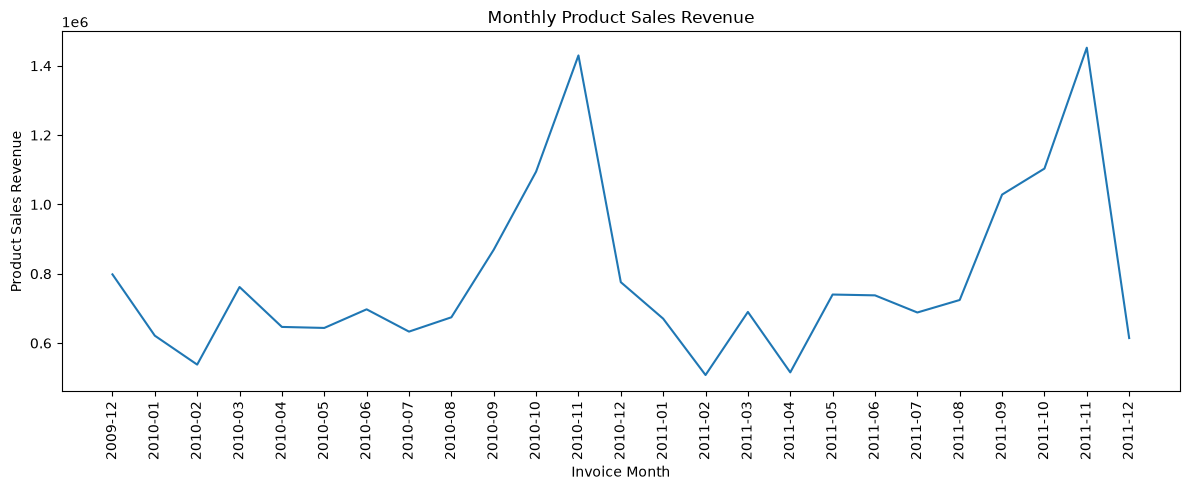

In [8]:
plt.figure(figsize=(12, 5))
plt.plot(monthly_sales["invoice_month"], monthly_sales["product_sales_revenue"])
plt.xticks(rotation=90)
plt.title("Monthly Product Sales Revenue")
plt.xlabel("Invoice Month")
plt.ylabel("Product Sales Revenue")
plt.tight_layout()
plt.show()

## Country Performance

In [9]:
country_performance = (
    clean_product_sales
    .groupby("country")
    .agg(
        product_sales_revenue=("revenue", "sum"),
        orders=("invoice", "nunique"),
        customers=("customer_id", "nunique"),
        quantity_sold=("quantity", "sum")
    )
    .reset_index()
    .sort_values("product_sales_revenue", ascending=False)
)

country_performance["average_order_value"] = (
    country_performance["product_sales_revenue"] / country_performance["orders"]
)

country_performance.head(15)

,country,product_sales_revenue,orders,customers,quantity_sold,average_order_value
40,United Kingdom,16810878.72,36217,5336,9176519,464.170934
11,EIRE,625037.53,594,5,336101,1052.251734
26,Netherlands,549773.41,216,22,383625,2545.247269
15,Germany,383419.24,756,107,223091,507.168307
14,France,311147.02,599,94,270583,519.444107
0,Australia,167800.01,89,15,103753,1885.393371
34,Spain,97994.50,147,41,49999,666.629252
36,Switzerland,94024.59,85,22,52612,1106.171647
35,Sweden,86319.14,99,19,88537,871.910505
10,Denmark,67422.69,42,12,237406,1605.302143


The United Kingdom dominates product sales revenue, while countries such as EIRE, Netherlands, Australia, Denmark, and Japan show higher average order values, suggesting possible wholesale or bulk purchasing behavior.

## Product Performance

In [10]:
product_performance = (
    clean_product_sales
    .groupby(["stockcode", "description"])
    .agg(
        product_sales_revenue=("revenue", "sum"),
        quantity_sold=("quantity", "sum"),
        orders=("invoice", "nunique"),
        customers=("customer_id", "nunique"),
        average_unit_price=("price", "mean")
    )
    .reset_index()
    .sort_values("product_sales_revenue", ascending=False)
)

product_performance.head(20)

,stockcode,description,product_sales_revenue,quantity_sold,orders,customers,average_unit_price
1875,22423,REGENCY CAKESTAND 3 TIER,330590.32,26478,3918,1314,14.190418
4971,85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,94142,5356,1490,3.075422
3335,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,1,2.080000
3695,47566,PARTY BUNTING,148318.28,28200,2674,894,5.718177
4940,85099B,JUMBO BAG RED RETROSPOT,145961.83,77280,3245,860,2.365692
4613,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807,1010,1.859034
1465,22086,PAPER CHAIN KIT 50'S CHRISTMAS,117760.29,35084,2018,896,3.369927
2790,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,138,1.468480
4035,79321,CHILLI LIGHTS,80540.88,15841,1135,304,6.290666
4201,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,71300.40,31409,756,300,3.342535


Product revenue rankings are based on gross product sales. Some top products include one-off bulk orders, so product rankings should be interpreted together with order count and customer count.

In [11]:
top_products_by_quantity = product_performance.sort_values(
    "quantity_sold",
    ascending=False
).head(20)

top_products_by_quantity

,stockcode,description,product_sales_revenue,quantity_sold,orders,customers,average_unit_price
4146,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,24445.61,106139,1019,482,0.283121
4971,85123A,WHITE HANGING HEART T-LIGHT HOLDER,257546.20,94142,5356,1490,3.075422
3335,23843,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,1,2.080000
4613,84879,ASSORTED COLOUR BIRD ORNAMENT,129324.49,80082,2807,1010,1.859034
2790,23166,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,138,1.468480
4940,85099B,JUMBO BAG RED RETROSPOT,145961.83,77280,3245,860,2.365692
120,17003,BROCADE RING PURSE,14766.42,70369,456,215,0.302727
1374,21977,PACK OF 60 PINK PAISLEY CAKE CASES,28081.73,56061,1993,767,0.711244
4774,84991,60 TEATIME FAIRY CAKE CASES,27041.21,54028,2127,822,0.664438
1593,22197,SMALL POPCORN HOLDER,42699.89,48561,1407,426,1.039720


## Return / Cancellation Impact

In [12]:
non_product_stockcodes = [
    "M",
    "AMAZONFEE",
    "POST",
    "B",
    "BANK CHARGES",
    "C2",
    "DOT",
    "PADS"
]

clean_all_transactions["is_non_product_transaction"] = (
    clean_all_transactions["stockcode"].isin(non_product_stockcodes) |
    clean_all_transactions["description"].str.upper().str.contains(
        "AMAZON FEE|POSTAGE|MANUAL|ADJUST BAD DEBT|BANK CHARGES|DOTCOM POSTAGE",
        na=False
    )
)

product_transactions = clean_all_transactions[
    clean_all_transactions["is_non_product_transaction"] == False
].copy()

In [13]:
positive_transaction_revenue = clean_all_transactions.loc[
    (clean_all_transactions["quantity"] > 0) &
    (clean_all_transactions["is_cancelled"] == False),
    "revenue"
].sum()

transaction_return_cancellation_revenue = clean_all_transactions.loc[
    clean_all_transactions["quantity"] < 0,
    "revenue"
].sum()

transaction_net_revenue = clean_all_transactions["revenue"].sum()

product_return_cancellation_revenue = product_transactions.loc[
    product_transactions["quantity"] < 0,
    "revenue"
].sum()

return_cancellation_summary = pd.DataFrame({
    "metric": [
        "positive_transaction_revenue",
        "transaction_return_cancellation_revenue",
        "transaction_net_revenue",
        "transaction_return_cancellation_rate",
        "product_sales_revenue",
        "product_return_cancellation_revenue",
        "product_return_cancellation_rate"
    ],
    "value": [
        positive_transaction_revenue,
        transaction_return_cancellation_revenue,
        transaction_net_revenue,
        abs(transaction_return_cancellation_revenue) / positive_transaction_revenue,
        clean_product_sales["revenue"].sum(),
        product_return_cancellation_revenue,
        abs(product_return_cancellation_revenue) / clean_product_sales["revenue"].sum()
    ]
})

def format_metric(row):
    if "rate" in row["metric"]:
        return f"{row['value']:.2%}"
    else:
        return f"{row['value']:,.2f}"

return_cancellation_summary["value_formatted"] = return_cancellation_summary.apply(
    format_metric,
    axis=1
)

return_cancellation_summary

,metric,value,value_formatted
0,positive_transaction_revenue,2.047626e+07,"20,476,260.45"
1,transaction_return_cancellation_revenue,-1.462424e+06,"-1,462,424.18"
2,transaction_net_revenue,1.901421e+07,"19,014,209.84"
3,transaction_return_cancellation_rate,7.142047e-02,7.14%
4,product_sales_revenue,1.965601e+07,"19,656,007.51"
5,product_return_cancellation_revenue,-7.459196e+05,"-745,919.63"
6,product_return_cancellation_rate,3.794868e-02,3.79%


## EDA Summary

This notebook analyzed overall product sales performance, monthly sales trends, country-level performance, product-level performance, and return/cancellation impact.

Key outputs from this notebook include:
- KPI overview table
- Monthly product sales trend table
- Country performance table
- Product performance table
- Return and cancellation impact summary

These outputs will be used for Tableau dashboard development and later business insight reporting.

In [14]:
kpi_overview.to_csv("../data/processed/kpi_overview.csv", index=False)
monthly_sales.to_csv("../data/processed/monthly_sales.csv", index=False)
country_performance.to_csv("../data/processed/country_performance.csv", index=False)
product_performance.to_csv("../data/processed/product_performance.csv", index=False)
top_products_by_quantity.to_csv("../data/processed/top_products_by_quantity.csv", index=False)
return_cancellation_summary.to_csv("../data/processed/return_cancellation_summary.csv", index=False)

print("EDA summary tables exported successfully.")

EDA summary tables exported successfully.
